### Unsupervised Learning - k-means Clustering

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk

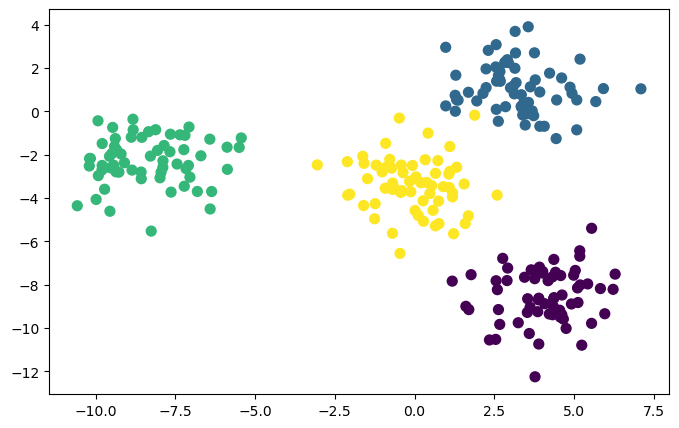

In [4]:
# Generate data
from sklearn.datasets._samples_generator import make_blobs
X, y = make_blobs(n_samples=250, centers=4, random_state=500, cluster_std=1.25)

plt.figure(figsize=(8,5))
plt.scatter(X[:,0], X[:,1], s=50, c=y)
plt.show()

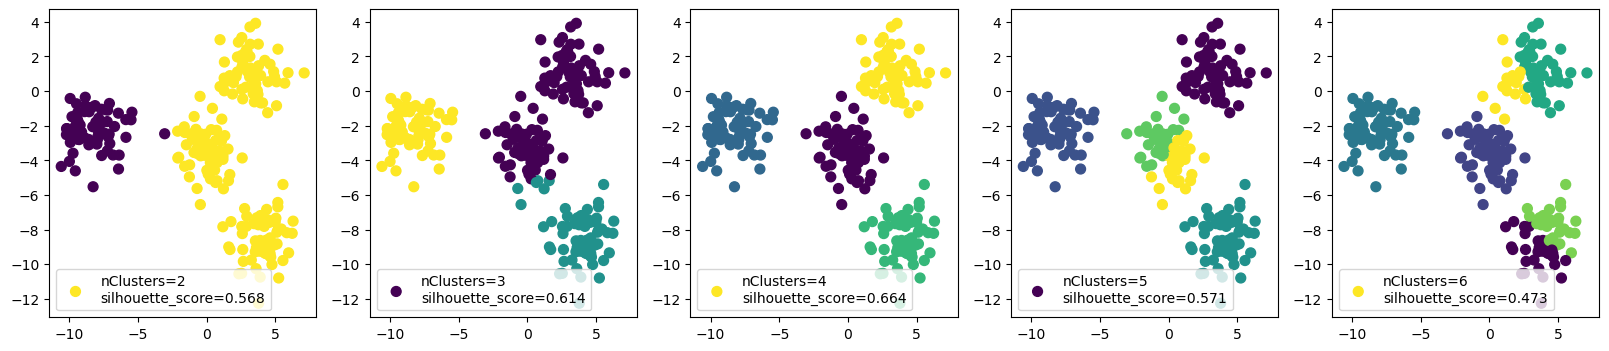

In [9]:
# Fit k-means clustering on the generated data

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for i,nClusters in enumerate([2, 3, 4, 5, 6]):
    model = sk.cluster.KMeans(n_clusters=nClusters)
    model.fit(X)
    y_pred = model.predict(X)

    silhouette_score = sk.metrics.silhouette_score(X, y_pred)
    
    ax[i].scatter(X[:, 0], X[:, 1], s=50, c=y_pred, label=f'nClusters={nClusters}\nsilhouette_score={round(silhouette_score,3)}')
    ax[i].legend()




### Guassian Mixture Model (GMM)

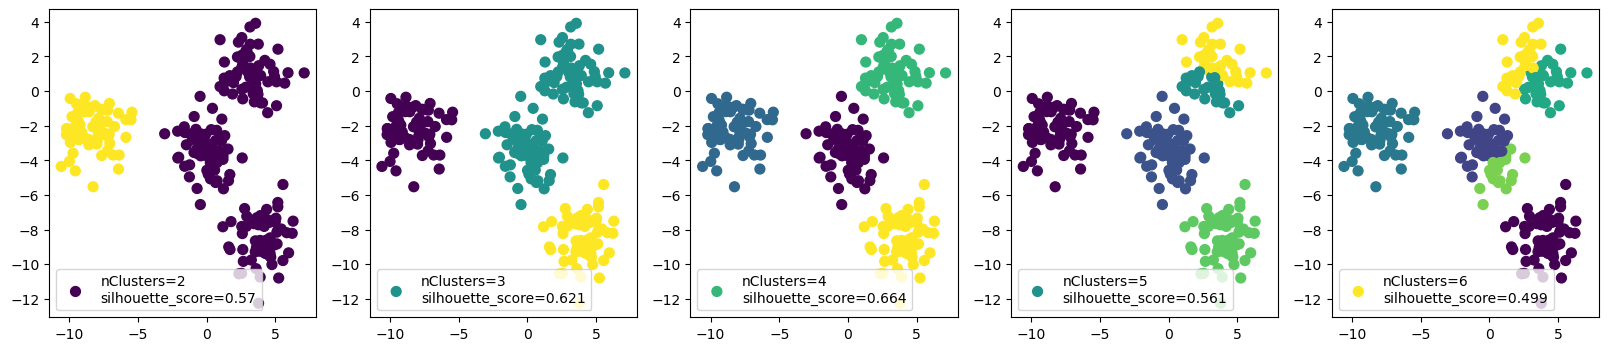

In [10]:
# Fit GMM on the generated data

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for i,nClusters in enumerate([2, 3, 4, 5, 6]):
    model = sk.mixture.GaussianMixture(n_components=nClusters, covariance_type='full')
    model.fit(X)
    y_pred = model.predict(X)

    silhouette_score = sk.metrics.silhouette_score(X, y_pred)
    
    ax[i].scatter(X[:, 0], X[:, 1], s=50, c=y_pred, label=f'nClusters={nClusters}\nsilhouette_score={round(silhouette_score,3)}')
    ax[i].legend()

### Spectral Clustering

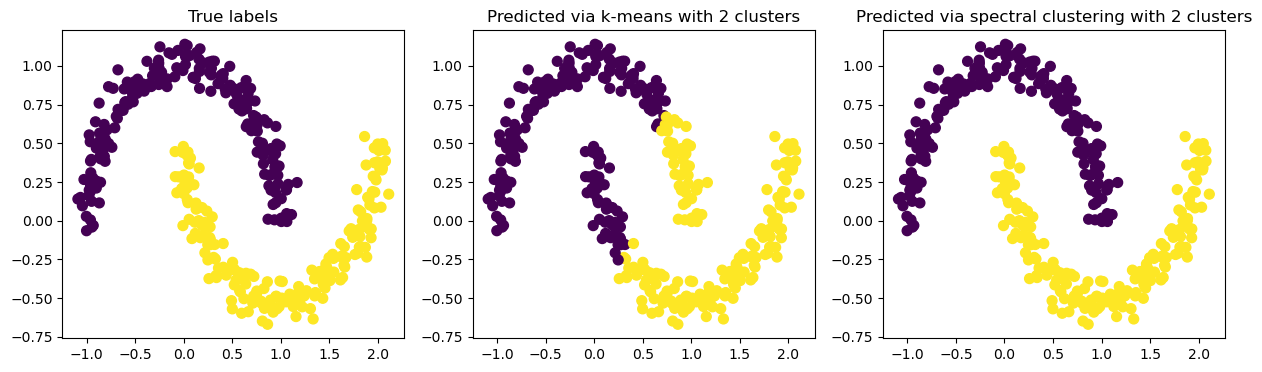

In [71]:
# Generate data 
X, y = sk.datasets.make_moons(n_samples=400, noise=0.07)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].set_title('True labels')
ax[0].scatter(X[:, 0], X[:, 1], s=50, c=y)

model = sk.cluster.KMeans(n_clusters=2)
model.fit(X)
y_pred = model.predict(X)
ax[1].set_title('Predicted via k-means with 2 clusters')
ax[1].scatter(X[:, 0], X[:, 1], s=50, c=y_pred)

sc = sk.cluster.SpectralClustering(n_clusters=2, affinity='rbf', gamma=12, assign_labels='kmeans')
sc.fit(X)
y_pred_sc = sc.labels_
ax[2].set_title('Predicted via spectral clustering with 2 clusters')
ax[2].scatter(X[:, 0], X[:, 1], s=50, c=y_pred_sc)

plt.show()

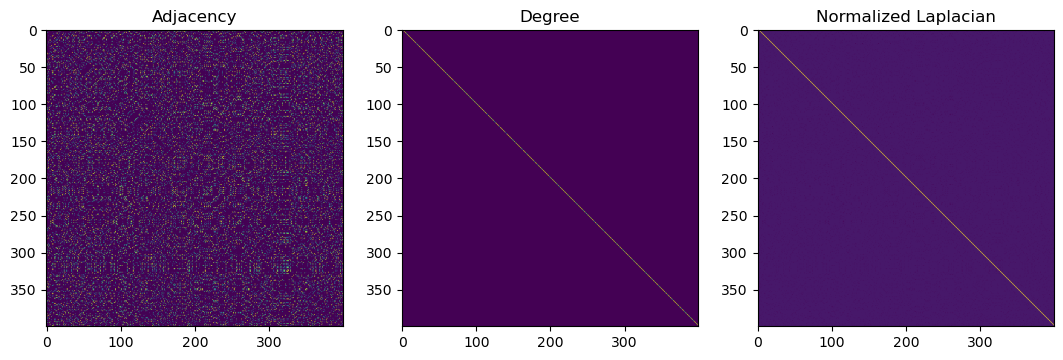

In [75]:
# Build adjacency matrix
A = sk.metrics.pairwise.rbf_kernel(X, X, gamma=10)
np.fill_diagonal(A, 0)

# Build degree matrix
degrees = A.sum(axis=1)
D = np.diag(degrees)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees + 1e-12))

# L = D - A (unnormalized laplacian)
# Normalize graph laplacian
D_inv_sqrt = np.sqrt(np.linalg.inv(D))
L = np.eye(X.shape[0]) - D_inv_sqrt @ A @ D_inv_sqrt

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(A)
ax[1].imshow(D)
ax[2].imshow(L)

ax[0].set_title('Adjacency')
ax[1].set_title('Degree')
ax[2].set_title('Normalized Laplacian')
plt.show()

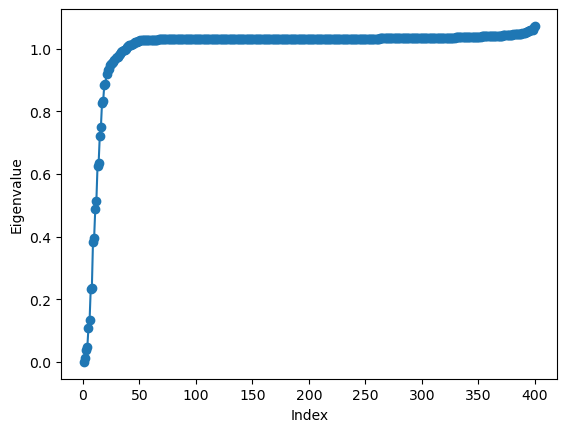

Estimated number of clusters: 8


In [76]:
# Eigendecompose graph laplacian
eigvals, eigvecs = np.linalg.eigh(L) # use eigh for symmetric matrices to guarantee real and sorted eigenvalues (it is also faster)

# Identify eigengap heuristic
plt.plot(np.arange(1, len(eigvals)+1), eigvals, marker='o')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.show()

gaps = np.diff(eigvals)
k = np.argmax(gaps[:20]) + 1
print(f"Estimated number of clusters: {k}")

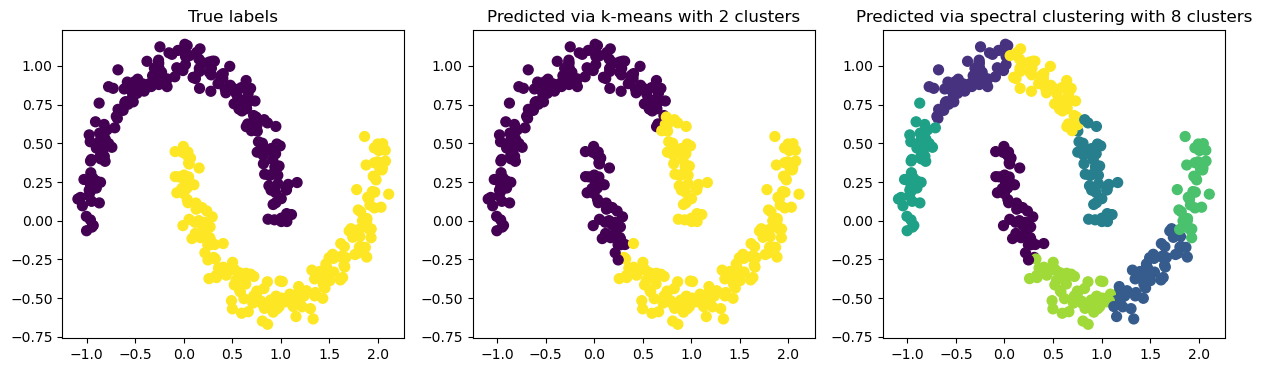

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].set_title('True labels')
ax[0].scatter(X[:, 0], X[:, 1], s=50, c=y)

model = sk.cluster.KMeans(n_clusters=2)
model.fit(X)
y_pred = model.predict(X)
ax[1].set_title('Predicted via k-means with 2 clusters')
ax[1].scatter(X[:, 0], X[:, 1], s=50, c=y_pred)

U = eigvecs[:, :k]
row_norms = np.linalg.norm(U, axis=1, keepdims=True)
U_norm = U / (row_norms + 1e-12)
sc = sk.cluster.KMeans(n_clusters=k)
sc.fit(U_norm)
y_pred_sc = sc.predict(U_norm)
ax[2].set_title(f'Predicted via spectral clustering with {k} clusters')
ax[2].scatter(X[:, 0], X[:, 1], s=50, c=y_pred_sc)

plt.show()